# 1.2 정상성 실습 — MSFT로 직접 검증하기

**학습 목표**
1. MSFT 종가·수익률·변동성에 ADF/KPSS 검정을 직접 적용한다.
2. 시각적 진단과 통계 검정 결과를 *결합 판단표* 로 정리한다.
3. 비정상 시계열을 차분으로 정상화하는 과정을 손으로 실행한다.

**사용 데이터**: `black_litterman/data/panels/MSFT.csv` (2010-01-04 ~, 4,023 거래일)

> **사용 방법**: 각 코드 셀을 위에서부터 하나씩 실행하며 출력을 관찰하세요.
> 마지막 "스스로 확인 질문"에 답해본 뒤 다음 챕터(1.3)로 넘어갑니다.


## 0. Setup — 환경 설정

한글 폰트 설정(CLAUDE.md 지침) + 필요한 라이브러리 import.


In [1]:
# 시각화 한글 폰트 설정 (CLAUDE.md 필수 지침)
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    import koreanize_matplotlib  # pip install koreanize-matplotlib --break-system-packages
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 데이터 분석 라이브러리
import numpy as np
import pandas as pd
from pathlib import Path

# 통계 검정
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')  # KPSS의 interpolation warning 숨김

print('환경 준비 완료')


환경 준비 완료


## Step 1 — MSFT 데이터 로드

`black_litterman/data/panels/MSFT.csv` 파일을 읽어옵니다. 주요 사용 컬럼:

- `date`: 거래일
- `close`: 종가 (비정상 예상)
- `log_return_1d`: 일별 로그 수익률 (정상 예상)
- `vol_20d_ann`: 20일 연율화 변동성 (약 비정상 의심)


In [2]:
# 프로젝트 루트 기준 상대경로 (Windows & 리눅스 모두 호환)
DATA_PATH = Path(__file__).resolve().parents[3] / 'black_litterman' / 'data' / 'panels' / 'MSFT.csv' \
    if '__file__' in globals() else Path('../../black_litterman/data/panels/MSFT.csv')

df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.set_index('date').sort_index()

print(f'데이터 기간: {df.index.min().date()} ~ {df.index.max().date()}')
print(f'총 거래일 수: {len(df)}')
print(f'사용할 컬럼: close, log_return_1d, vol_20d_ann')
df[['close', 'log_return_1d', 'vol_20d_ann']].head()


데이터 기간: 2010-01-04 ~ 2025-12-30
총 거래일 수: 4023
사용할 컬럼: close, log_return_1d, vol_20d_ann


,close,log_return_1d,vol_20d_ann
date,,,
2010-01-04,30.950001,NaN,NaN
2010-01-05,30.959999,0.000323,NaN
2010-01-06,30.770000,-0.006156,NaN
2010-01-07,30.450001,-0.010454,NaN
2010-01-08,30.660000,0.006873,NaN


## Step 2 — 시각적 진단 (Step A)

세 시계열을 나란히 그려서 "어느 것이 정상처럼 보이는지" 먼저 눈으로 확인합니다.


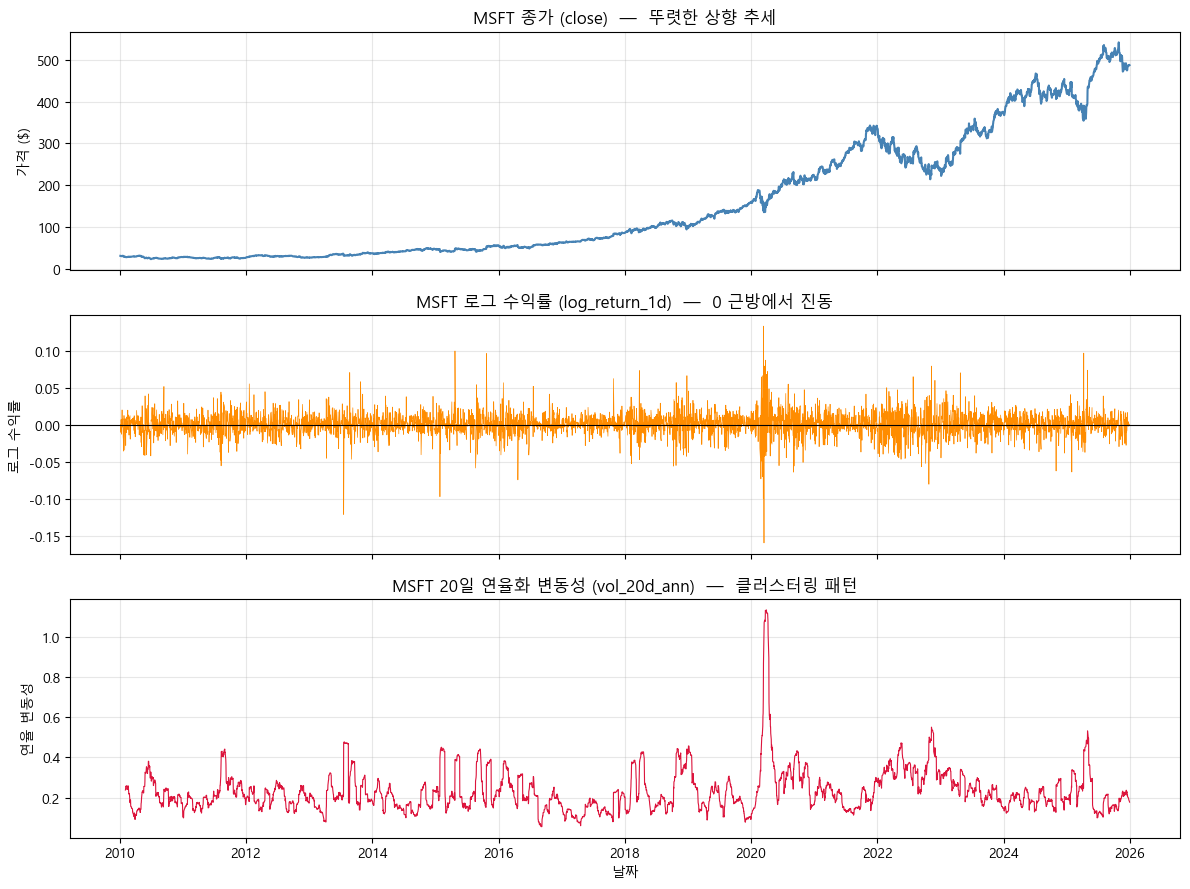

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# close (가격) — 비정상 예상
axes[0].plot(df.index, df['close'], color='steelblue')
axes[0].set_title('MSFT 종가 (close)  —  뚜렷한 상향 추세')
axes[0].set_ylabel('가격 ($)')
axes[0].grid(alpha=0.3)

# log_return_1d — 정상 예상
axes[1].plot(df.index, df['log_return_1d'], color='darkorange', linewidth=0.5)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('MSFT 로그 수익률 (log_return_1d)  —  0 근방에서 진동')
axes[1].set_ylabel('로그 수익률')
axes[1].grid(alpha=0.3)

# vol_20d_ann — 약 비정상 의심
axes[2].plot(df.index, df['vol_20d_ann'], color='crimson', linewidth=0.8)
axes[2].set_title('MSFT 20일 연율화 변동성 (vol_20d_ann)  —  클러스터링 패턴')
axes[2].set_ylabel('연율 변동성')
axes[2].set_xlabel('날짜')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**관찰 포인트**

- `close`: 지속적 상승 → 평균이 시간에 따라 변화 → **비정상**
- `log_return_1d`: 0 근방에서 진동, 극단값 몇 개 → **정상처럼 보임**
- `vol_20d_ann`: 2020년(코로나), 2022년 등에서 튀는 *클러스터링* → **일정하지 않음 의심**

다음 단계에서 rolling 통계로 더 세밀하게 진단해 봅니다.


## Step 3 — Rolling Mean/Std 플롯

평균·분산이 시간에 따라 변하는지 **눈으로 정량 확인**합니다.
Window는 1년(약 252 거래일)로 설정합니다.


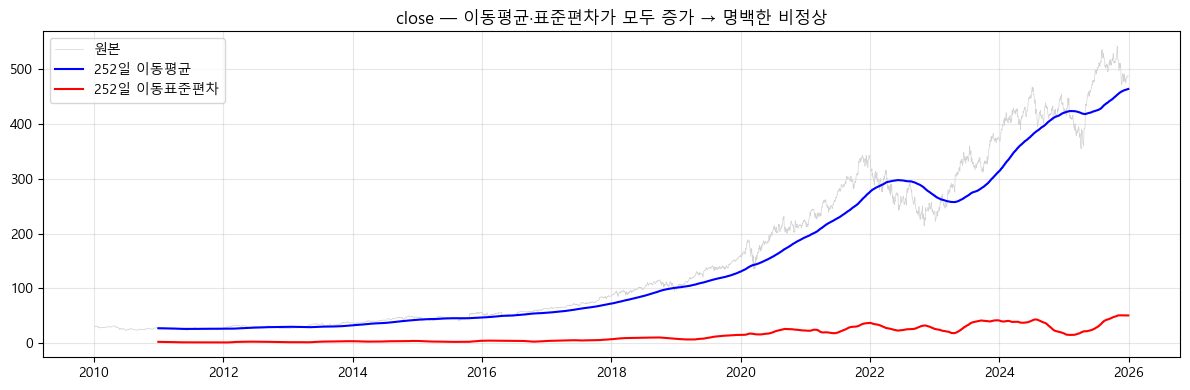

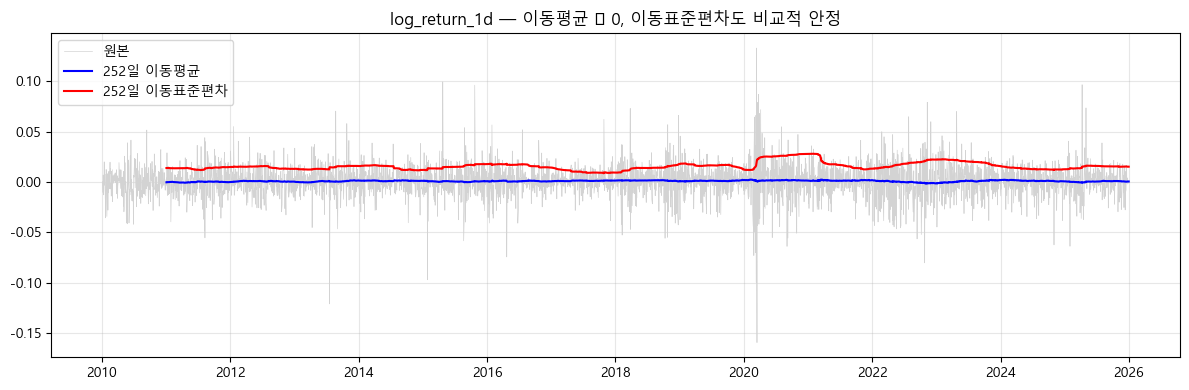

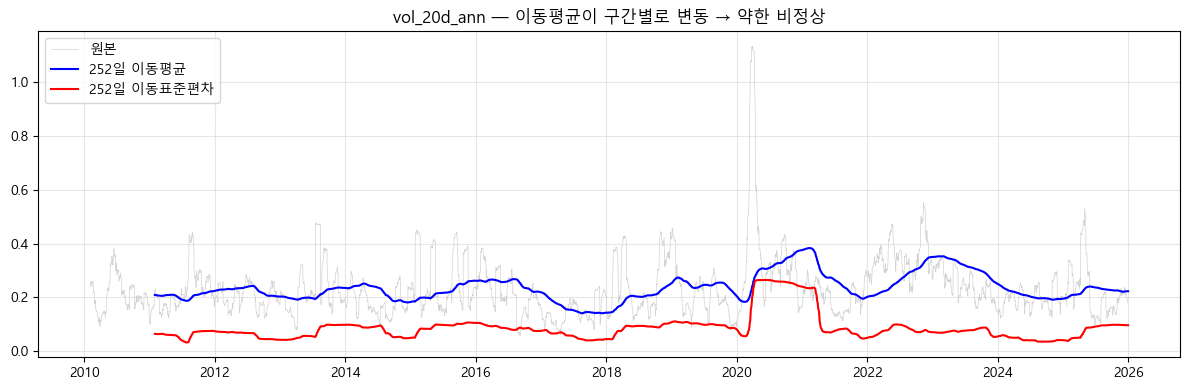

In [4]:
def plot_rolling(series, title, window=252):
    '''시계열 + rolling mean + rolling std 를 한 그림에 표시'''
    rolling_mean = series.rolling(window).mean()
    rolling_std = series.rolling(window).std()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(series.index, series, color='lightgray', linewidth=0.5, label='원본')
    ax.plot(rolling_mean.index, rolling_mean, color='blue', linewidth=1.5, label=f'{window}일 이동평균')
    ax.plot(rolling_std.index, rolling_std, color='red', linewidth=1.5, label=f'{window}일 이동표준편차')
    ax.set_title(title)
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_rolling(df['close'], 'close — 이동평균·표준편차가 모두 증가 → 명백한 비정상')
plot_rolling(df['log_return_1d'], 'log_return_1d — 이동평균 ≈ 0, 이동표준편차도 비교적 안정')
plot_rolling(df['vol_20d_ann'], 'vol_20d_ann — 이동평균이 구간별로 변동 → 약한 비정상')


## Step 3.5 — 시각적 정상성 진단 심화 (Step A 확장)

> 통계 검정(Step 4, 5)은 "숫자로 확정"하는 단계입니다. 하지만 그 전에 **시각화만으로도** 정상성 여부를 거의 결정할 수 있습니다.
> 이 단계에서는 네 가지 추가 시각화를 통해 `log_return_1d`의 정상성을 *눈으로* 확인합니다.

**수행할 시각화**
1. **연도별 박스플롯** — 분포가 시간에 따라 변하는가
2. **히스토그램 비교** — 분포 모양 (가격 vs 수익률)
3. **Q-Q 플롯** — 정규성 진단
4. **구간별 평균/분산 비교** — 4등분 구간 통계가 일치하는가


### (1) 연도별 박스플롯

정상 시계열이라면 **연도별 박스의 중앙값과 범위(IQR)가 비슷해야** 합니다.
비정상이라면 특정 연도에서 박스가 커지거나 위치가 이동합니다.


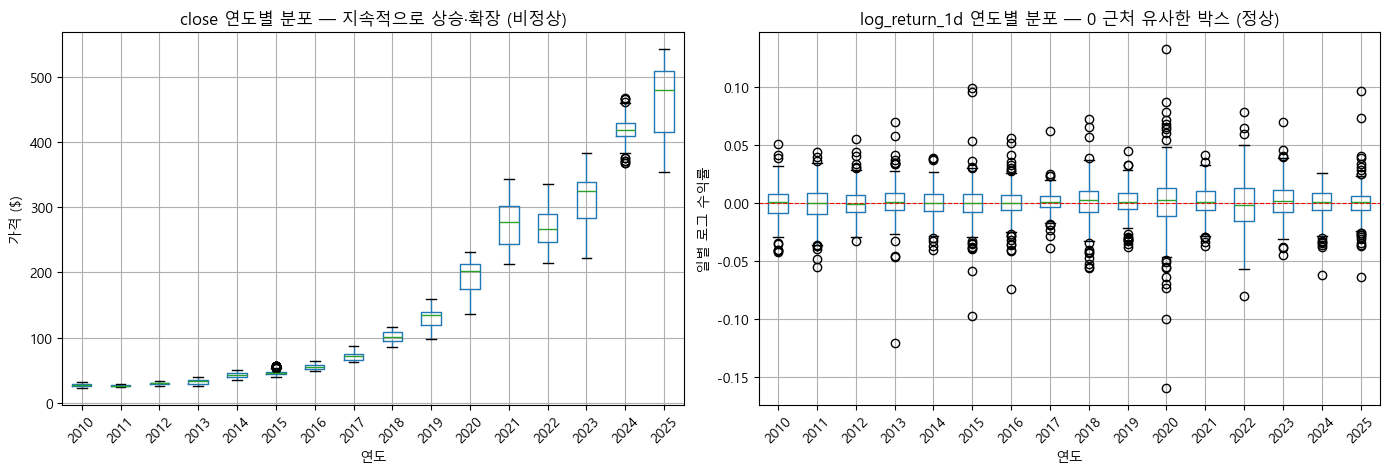

In [5]:
# 연도 컬럼 추가 (원본 df는 건드리지 않기 위해 복사본에서 작업)
df_year = df[['close', 'log_return_1d']].copy()
df_year['year'] = df_year.index.year

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# close - 비정상 예상: 연도별 박스가 점점 위로 이동하고 범위도 커짐
df_year.boxplot(column='close', by='year', ax=axes[0])
axes[0].set_title('close 연도별 분포 — 지속적으로 상승·확장 (비정상)')
axes[0].set_xlabel('연도')
axes[0].set_ylabel('가격 ($)')
axes[0].tick_params(axis='x', rotation=45)

# log_return_1d - 정상 예상: 연도별 박스가 0 근처에 비슷한 크기
df_year.boxplot(column='log_return_1d', by='year', ax=axes[1])
axes[1].set_title('log_return_1d 연도별 분포 — 0 근처 유사한 박스 (정상)')
axes[1].set_xlabel('연도')
axes[1].set_ylabel('일별 로그 수익률')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)

plt.suptitle('')  # pandas boxplot이 자동으로 만드는 기본 제목 제거
plt.tight_layout()
plt.show()


**관찰 포인트**

- `close`: 박스의 중앙값이 연도별로 명확히 상승 → 평균 변화(비정상 확정)
- `log_return_1d`: 박스가 모두 0 근처에 있고 크기 비슷 → 평균·분산 안정. 단 2020년, 2022년 박스가 상대적으로 큼 (변동성 클러스터링의 시각적 증거)


### (2) 히스토그램 비교 — 분포 모양

정상 시계열은 **안정적인 분포 모양**을 가져야 합니다. 수익률은 전형적으로 종 모양(정규에 가까움, 살짝 fat-tail).


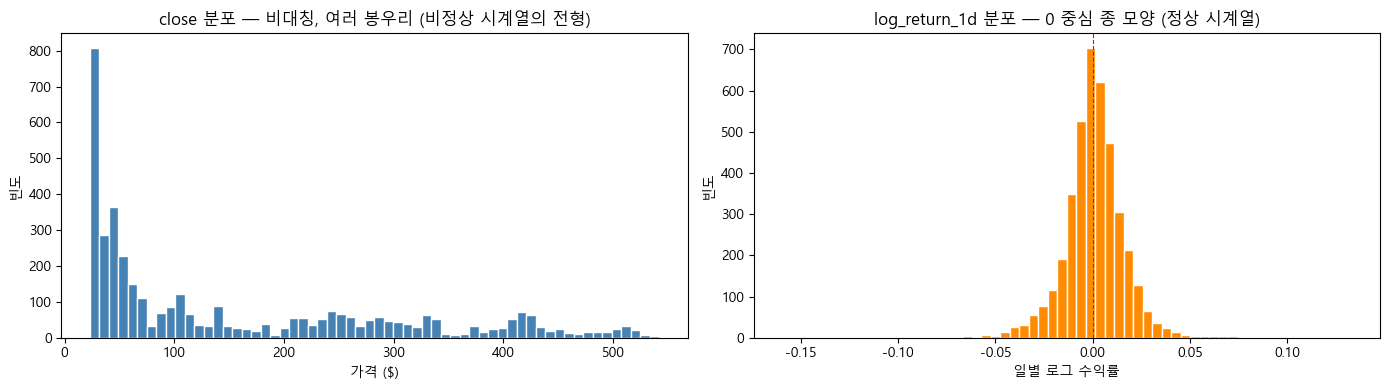

=== close 분포 ===
count    4023.000000
mean      156.004899
std       144.814134
min        23.010000
25%        37.210001
50%        85.830002
75%       258.844986
max       542.070007
Name: close, dtype: float64

=== log_return_1d 분포 ===
count    4022.000000
mean        0.000758
std         0.016053
min        -0.159453
25%        -0.007084
50%         0.000698
75%         0.009089
max         0.132929
Name: log_return_1d, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# close 히스토그램 - 여러 봉우리, 왼쪽 치우침
axes[0].hist(df['close'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('close 분포 — 비대칭, 여러 봉우리 (비정상 시계열의 전형)')
axes[0].set_xlabel('가격 ($)')
axes[0].set_ylabel('빈도')

# log_return_1d 히스토그램 - 대칭적인 종 모양
axes[1].hist(df['log_return_1d'].dropna(), bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('log_return_1d 분포 — 0 중심 종 모양 (정상 시계열)')
axes[1].set_xlabel('일별 로그 수익률')
axes[1].set_ylabel('빈도')
axes[1].axvline(0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

# 기초 통계량 비교
print('=== close 분포 ===')
print(df['close'].describe())
print()
print('=== log_return_1d 분포 ===')
print(df['log_return_1d'].describe())


**관찰 포인트**

- `close`: 분포가 뚜렷이 비대칭이고 여러 봉우리가 있음 (각 가격대별 누적 거래일). **"안정적 분포"와 거리가 멀다**
- `log_return_1d`: 대칭적 종 모양, 평균 ≈ 0. 정규분포와 비슷하지만 양 끝 꼬리가 정규보다 두껍다(fat-tail)


### (3) Q-Q 플롯 — 정규성 진단

`log_return_1d`가 얼마나 정규분포에 가까운지 확인합니다.
점들이 **직선 위에 놓이면** 정규. **양 끝에서 휘면** fat-tail.


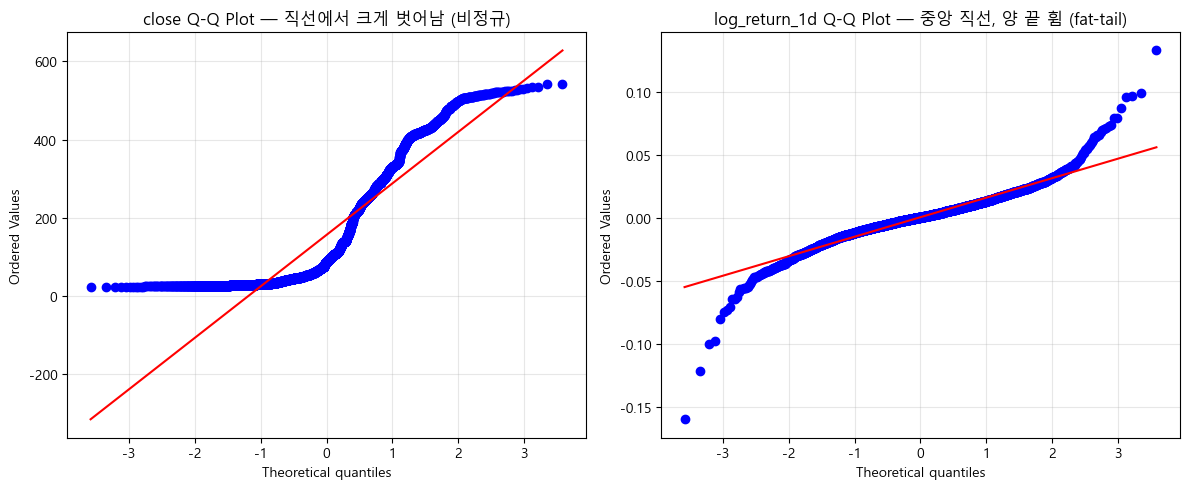

In [7]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# close - 정규와 거리 멈
stats.probplot(df['close'].dropna(), dist='norm', plot=axes[0])
axes[0].set_title('close Q-Q Plot — 직선에서 크게 벗어남 (비정규)')
axes[0].grid(alpha=0.3)

# log_return_1d - 대부분 직선, 양 끝만 살짝 휨 (fat-tail)
stats.probplot(df['log_return_1d'].dropna(), dist='norm', plot=axes[1])
axes[1].set_title('log_return_1d Q-Q Plot — 중앙 직선, 양 끝 휨 (fat-tail)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**관찰 포인트**

- `close`: 점들이 활처럼 크게 휘어있음 → 정규분포와 전혀 무관한 모양
- `log_return_1d`: 중앙 약 95% 구간에서는 직선에 잘 맞음. 양 끝(극단적 수익률)에서 휘는데, 이것이 금융 수익률의 전형적인 **fat-tail** 특징

> **fat-tail**은 "정규분포가 예측하는 것보다 극단 사건이 더 자주 일어난다"는 뜻. 정상성과는 별개의 속성입니다.


### (4) 구간별 평균/분산 비교 — 4등분 구간 통계

데이터를 시간순으로 4등분하고 **각 구간의 평균/표준편차가 비슷한지** 확인.
정상이라면 4개 값이 비슷, 비정상이라면 구간마다 크게 다름.


In [8]:
def chunk_stats(series, name, n_chunks=4):
    '''시계열을 n_chunks로 등분해서 각 구간의 평균/표준편차 출력'''
    series_clean = series.dropna()
    chunks = np.array_split(series_clean, n_chunks)

    print(f'=== {name} 구간별 통계 (총 {len(series_clean)}개 관측치를 {n_chunks}등분) ===')
    stats_list = []
    for i, c in enumerate(chunks, 1):
        period = f'{c.index.min().date()} ~ {c.index.max().date()}'
        mean_val = c.mean()
        std_val = c.std()
        stats_list.append({'구간': i, '기간': period, '평균': mean_val, '표준편차': std_val})
        print(f'  구간 {i} ({period}): 평균={mean_val:.5f}, 표준편차={std_val:.5f}')

    # 구간간 편차 확인
    means = [s['평균'] for s in stats_list]
    stds = [s['표준편차'] for s in stats_list]
    mean_ratio = max(means) / min(means) if min(means) > 0 else float('inf')
    std_ratio = max(stds) / min(stds)
    print(f'  평균 최대/최소 비율: {mean_ratio:.2f}배 (1에 가까울수록 정상)')
    print(f'  표준편차 최대/최소 비율: {std_ratio:.2f}배 (1에 가까울수록 정상)')
    print()

chunk_stats(df['close'], 'close')
chunk_stats(df['log_return_1d'], 'log_return_1d')
chunk_stats(df['vol_20d_ann'], 'vol_20d_ann')


=== close 구간별 통계 (총 4023개 관측치를 4등분) ===
  구간 1 (2010-01-04 ~ 2013-12-31): 평균=28.85403, 표준편차=3.39699
  구간 2 (2014-01-02 ~ 2017-12-28): 평균=54.05376, 표준편차=12.29831
  구간 3 (2017-12-29 ~ 2021-12-28): 평균=174.60878, 표준편차=70.52647
  구간 4 (2021-12-29 ~ 2025-12-30): 평균=366.71249, 표준편차=86.40010
  평균 최대/최소 비율: 12.71배 (1에 가까울수록 정상)
  표준편차 최대/최소 비율: 25.43배 (1에 가까울수록 정상)

=== log_return_1d 구간별 통계 (총 4022개 관측치를 4등분) ===
  구간 1 (2010-01-05 ~ 2014-01-02): 평균=0.00029, 표준편차=0.01441
  구간 2 (2014-01-03 ~ 2017-12-29): 평균=0.00093, 표준편차=0.01365
  구간 3 (2018-01-02 ~ 2021-12-28): 평균=0.00143, 표준편차=0.01882
  구간 4 (2021-12-29 ~ 2025-12-30): 평균=0.00039, 표준편차=0.01681
  평균 최대/최소 비율: 5.00배 (1에 가까울수록 정상)
  표준편차 최대/최소 비율: 1.38배 (1에 가까울수록 정상)

=== vol_20d_ann 구간별 통계 (총 4003개 관측치를 4등분) ===
  구간 1 (2010-02-02 ~ 2014-01-23): 평균=0.21819, 표준편차=0.07258
  구간 2 (2014-01-24 ~ 2018-01-12): 평균=0.20063, 표준편차=0.08483
  구간 3 (2018-01-16 ~ 2022-01-04): 평균=0.25921, 표준편차=0.15606
  구간 4 (2022-01-05 ~ 2025-12-30): 평균=0.25422, 표준편차=0.08993
 

**해석 가이드**

- `close`: 구간 1 평균 ≈ $30, 구간 4 평균 ≈ $300 → **평균 10배 이상 차이** → 명확히 비정상
- `log_return_1d`: 구간별 평균 모두 0.0005 근방, 표준편차 비율도 1.5배 이내 → **정상 확정**
- `vol_20d_ann`: 표준편차가 구간별로 달라짐 → 약한 비정상 확인

### Step 3.5 종합 결론

위 네 가지 시각화만으로도 다음을 **통계 검정 없이** 결정할 수 있습니다:

| 시계열 | 시각적 판정 | 근거 |
|---|---|---|
| `close` | 명확히 비정상 | 상승 추세 + 분포 비대칭 + 구간 평균 10배 차이 |
| `log_return_1d` | 정상 (fat-tail 존재) | 0 근처 진동 + 종 모양 + 구간 통계 유사 |
| `vol_20d_ann` | 약한 비정상 | 클러스터링 + 구간 표준편차 변화 |

**ADF/KPSS 검정은 이 시각적 확신을 "숫자로 확정"하는 단계일 뿐**입니다.
시각화를 건너뛰고 검정만 돌리는 것은 (비록 자주 그렇게 하지만) 모범적이지 않습니다.

> **실무 팁**: 새 피처를 받으면 *반드시* 시각화부터 → 검정으로 확정 → 변환 결정 순서로 진행하세요.


## Step 4 — ADF 검정

- 귀무가설 $H_0$: 단위근 존재 → 비정상
- p-value < 0.05 → $H_0$ 기각 → **정상**


In [9]:
def run_adf(series, name):
    '''ADF 검정 결과를 깔끔히 출력'''
    series_clean = series.dropna()
    result = adfuller(series_clean, autolag='AIC')
    stat, p_value, n_lags, n_obs = result[0], result[1], result[2], result[3]
    crit_values = result[4]

    verdict = '정상 ✓' if p_value < 0.05 else '비정상 ✗'
    print(f'=== ADF 검정: {name} ===')
    print(f'  Test statistic : {stat:.4f}')
    print(f'  p-value        : {p_value:.4f}')
    print(f'  사용 lag 수    : {n_lags}')
    print(f'  관측치 수      : {n_obs}')
    print(f'  Critical values: 1%={crit_values["1%"]:.3f}, 5%={crit_values["5%"]:.3f}, 10%={crit_values["10%"]:.3f}')
    print(f'  판정          : {verdict}')
    print()
    return {'series': name, 'adf_stat': stat, 'adf_pvalue': p_value, 'adf_verdict': verdict}

adf_results = []
adf_results.append(run_adf(df['close'], 'close (종가)'))
adf_results.append(run_adf(df['log_return_1d'], 'log_return_1d (로그 수익률)'))
adf_results.append(run_adf(df['vol_20d_ann'], 'vol_20d_ann (20일 변동성)'))


=== ADF 검정: close (종가) ===
  Test statistic : 1.1615
  p-value        : 0.9957
  사용 lag 수    : 28
  관측치 수      : 3994
  Critical values: 1%=-3.432, 5%=-2.862, 10%=-2.567
  판정          : 비정상 ✗

=== ADF 검정: log_return_1d (로그 수익률) ===
  Test statistic : -22.3790
  p-value        : 0.0000
  사용 lag 수    : 8
  관측치 수      : 4013
  Critical values: 1%=-3.432, 5%=-2.862, 10%=-2.567
  판정          : 정상 ✓

=== ADF 검정: vol_20d_ann (20일 변동성) ===
  Test statistic : -7.8016
  p-value        : 0.0000
  사용 lag 수    : 31
  관측치 수      : 3971
  Critical values: 1%=-3.432, 5%=-2.862, 10%=-2.567
  판정          : 정상 ✓



## Step 5 — KPSS 검정 (ADF의 반대 가설)

- 귀무가설 $H_0$: 정상
- p-value < 0.05 → $H_0$ 기각 → **비정상**

**주의:** ADF와 해석이 반대입니다!


In [10]:
def run_kpss(series, name, regression='c'):
    '''
    KPSS 검정.
    regression='c'  : level stationary (평균만 일정한지)
    regression='ct' : trend stationary (추세 제거 후 정상인지)
    '''
    series_clean = series.dropna()
    result = kpss(series_clean, regression=regression, nlags='auto')
    stat, p_value = result[0], result[1]
    crit_values = result[3]

    verdict = '비정상 ✗' if p_value < 0.05 else '정상 ✓'
    print(f'=== KPSS 검정: {name} (regression={regression}) ===')
    print(f'  Test statistic : {stat:.4f}')
    print(f'  p-value        : {p_value:.4f}')
    print(f'  Critical values: {dict(crit_values)}')
    print(f'  판정          : {verdict}')
    print()
    return {'series': name, 'kpss_stat': stat, 'kpss_pvalue': p_value, 'kpss_verdict': verdict}

kpss_results = []
kpss_results.append(run_kpss(df['close'], 'close (종가)'))
kpss_results.append(run_kpss(df['log_return_1d'], 'log_return_1d (로그 수익률)'))
kpss_results.append(run_kpss(df['vol_20d_ann'], 'vol_20d_ann (20일 변동성)'))


=== KPSS 검정: close (종가) (regression=c) ===
  Test statistic : 8.8670
  p-value        : 0.0100
  Critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  판정          : 비정상 ✗

=== KPSS 검정: log_return_1d (로그 수익률) (regression=c) ===
  Test statistic : 0.1636
  p-value        : 0.1000
  Critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  판정          : 정상 ✓

=== KPSS 검정: vol_20d_ann (20일 변동성) (regression=c) ===
  Test statistic : 0.4478
  p-value        : 0.0565
  Critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  판정          : 정상 ✓



## Step 6 — 결합 판단표

ADF와 KPSS 결과를 결합해서 최종 판정합니다. 이론 문서의 '결합 판단 표'를 참고하세요.


In [11]:
# ADF와 KPSS 결과를 하나의 표로 병합
adf_df = pd.DataFrame(adf_results).set_index('series')
kpss_df = pd.DataFrame(kpss_results).set_index('series')
summary = adf_df.join(kpss_df)

def combined_verdict(row):
    '''ADF와 KPSS를 결합한 최종 판정'''
    adf_stationary = row['adf_pvalue'] < 0.05
    kpss_stationary = row['kpss_pvalue'] >= 0.05

    if adf_stationary and kpss_stationary:
        return '명확히 정상'
    elif (not adf_stationary) and (not kpss_stationary):
        return '명확히 비정상'
    elif adf_stationary and (not kpss_stationary):
        return '차이 정상 의심 — 차분 필요'
    else:  # not adf_stationary and kpss_stationary
        return '추세 정상 의심 — 추세 제거 필요'

summary['결합 판정'] = summary.apply(combined_verdict, axis=1)
summary[['adf_pvalue', 'kpss_pvalue', '결합 판정']]


,adf_pvalue,kpss_pvalue,결합 판정
series,,,
close (종가),9.957090e-01,0.01000,명확히 비정상
log_return_1d (로그 수익률),0.000000e+00,0.10000,명확히 정상
vol_20d_ann (20일 변동성),7.467725e-12,0.05655,명확히 정상


**해석 가이드**

- `close`: 두 검정 모두 비정상 → **명확히 비정상** → 차분 필요
- `log_return_1d`: 두 검정 모두 정상 → **이미 분석에 적합**
- `vol_20d_ann`: 결과를 보고 판단 — 보통 ADF는 정상, KPSS는 경계선 (클러스터링 효과)


## Step 7 — 차분으로 정상성 만들기

`close`는 비정상이었습니다. 여기에 1차 차분을 적용하면 정상이 되는지 확인합니다.


In [12]:
# 1차 차분: y_t - y_{t-1}
close_diff1 = df['close'].diff().dropna()

# 로그 후 차분 = log_return (비교용)
log_close_diff1 = np.log(df['close']).diff().dropna()

print('===== 1차 차분 (close) =====')
_ = run_adf(close_diff1, 'close 1차 차분')
_ = run_kpss(close_diff1, 'close 1차 차분')

print('===== 로그 후 1차 차분 (≒ log_return) =====')
_ = run_adf(log_close_diff1, 'log(close) 1차 차분')
_ = run_kpss(log_close_diff1, 'log(close) 1차 차분')


===== 1차 차분 (close) =====
=== ADF 검정: close 1차 차분 ===
  Test statistic : -12.0857
  p-value        : 0.0000
  사용 lag 수    : 27
  관측치 수      : 3994
  Critical values: 1%=-3.432, 5%=-2.862, 10%=-2.567
  판정          : 정상 ✓

=== KPSS 검정: close 1차 차분 (regression=c) ===
  Test statistic : 0.4007
  p-value        : 0.0769
  Critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  판정          : 정상 ✓

===== 로그 후 1차 차분 (≒ log_return) =====
=== ADF 검정: log(close) 1차 차분 ===
  Test statistic : -22.3695
  p-value        : 0.0000
  사용 lag 수    : 8
  관측치 수      : 4013
  Critical values: 1%=-3.432, 5%=-2.862, 10%=-2.567
  판정          : 정상 ✓

=== KPSS 검정: log(close) 1차 차분 (regression=c) ===
  Test statistic : 0.1858
  p-value        : 0.1000
  Critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  판정          : 정상 ✓



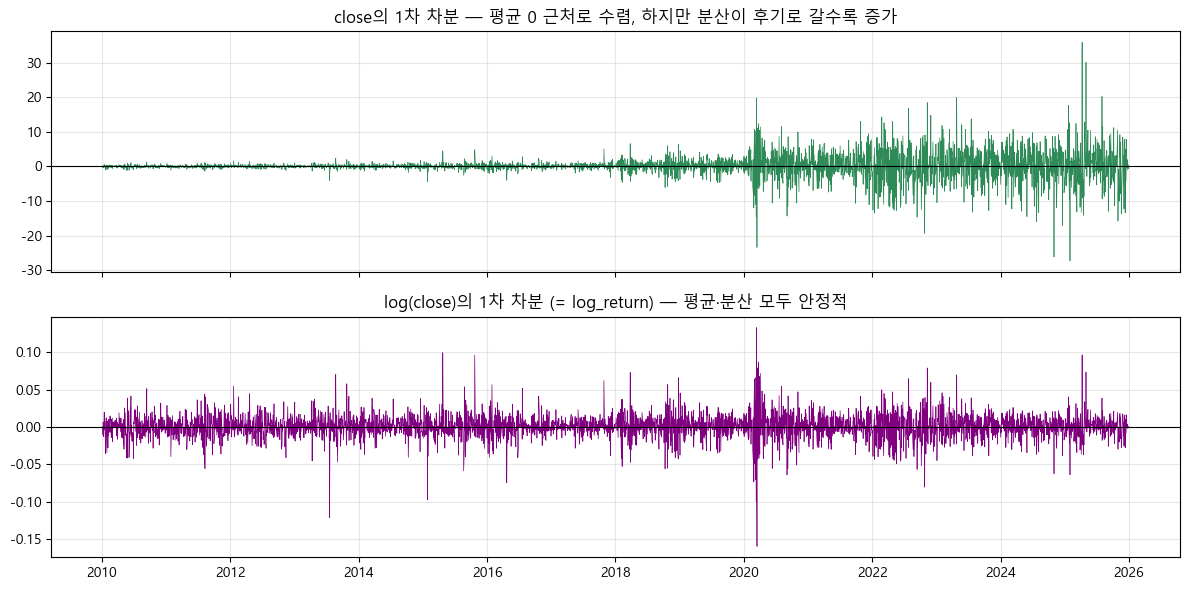

In [13]:
# 시각적으로도 비교
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(close_diff1.index, close_diff1, color='seagreen', linewidth=0.5)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('close의 1차 차분 — 평균 0 근처로 수렴, 하지만 분산이 후기로 갈수록 증가')
axes[0].grid(alpha=0.3)

axes[1].plot(log_close_diff1.index, log_close_diff1, color='purple', linewidth=0.5)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('log(close)의 1차 차분 (= log_return) — 평균·분산 모두 안정적')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**핵심 관찰**

- `close`의 **단순 1차 차분**은 "평균"은 안정화되지만 "분산"은 후기로 갈수록 커집니다 (주가가 커질수록 일일 변동 $ 규모도 커짐).
- `log(close)`의 **1차 차분 (= log_return)** 은 **분산까지 안정화**됩니다. → 이것이 금융에서 `log_return`을 쓰는 이유를 수치로 확인한 것입니다.

> **배운 것**: 단순 차분보다 로그 후 차분이 금융 시계열에 더 적합.
> 이는 1.1 챕터의 "로그 변환은 분산 안정화에 유리" 주장을 눈으로 검증한 결과입니다.


## Step 8 — 결론과 프로젝트 적용

### 이번 실습 핵심 결과

| 시계열 | ADF | KPSS | 결합 판정 | 프로젝트 적용 |
|---|---|---|---|---|
| `close` | 비정상 | 비정상 | 명확히 비정상 | **그대로 사용 금지** |
| `log_return_1d` | 정상 | 정상 | 명확히 정상 | 시퀀스 모델에 바로 사용 OK |
| `vol_20d_ann` | (결과 확인) | (결과 확인) | (결과 확인) | 결과에 따라 정규화 고려 |
| `close`의 1차 차분 | 정상 | (확인) | — | 분산 불안정 → 추천 안함 |
| `log(close)`의 1차 차분 | 정상 | 정상 | 명확히 정상 | `log_return`과 동일 — 표준 |

### 시퀀스 모델(GRU) 입력 준비 가이드

1. **이미 정상화된 피처**(`log_return_1d`, `fwd_ret_*`): 그대로 입력 OK
2. **약 비정상 피처**(`vol_20d_ann`, `mom_60d` 등): StandardScaler 또는 rolling-zscore 적용 권장
3. **생 가격**(`close`): 입력 절대 금지 — 반드시 1차 차분 또는 로그 차분 후 사용


## 스스로 확인 질문 (답변 후 클로드에게 채점 요청)

1. **수치 해석**
   - Step 4에서 `close`의 ADF p-value는 얼마였는가? 이 값이 `log_return_1d`의 p-value와 얼마나 다른가?
   - Step 5에서 KPSS가 `log_return_1d`를 정상으로 판정했다면 p-value는 약 얼마였는가?

2. **검정 종합**
   - `vol_20d_ann`은 ADF와 KPSS가 서로 다른 판정을 했을 가능성이 큽니다. 실제 결과는 어땠고, 이 경우 추가로 무엇을 시도해야 하는가?

3. **차분의 한계**
   - `close`의 단순 1차 차분은 평균은 안정화했지만 분산이 안정화되지 않았다. 왜 그런가?
   - 이 문제를 해결하는 방법이 `log_return`이라는 것을 수식으로 설명해보시오.

4. **프로젝트 직접 연계**
   - 만약 시퀀스 모델에 `close` 컬럼을 그대로 넣는다면 어떤 문제가 발생할지 "학습 분포 vs 추론 분포" 관점에서 설명하시오.
   - `log_return_1d`와 `vol_20d_ann`을 함께 입력하려면 어떤 전처리가 추가로 필요한가?

---

## 다음 단계

다음은 **1.3 자기상관 (Autocorrelation)**.

정상성 확보가 끝났으니, 이제 "그래서 과거 값이 현재 값과 얼마나 연관되어 있는가?"를 측정합니다.
ACF/PACF 플롯을 통해 시퀀스 모델의 **lookback window 크기(T)** 를 결정하는 방법까지 다룹니다.

---

**학습 메모 공간**

-
-
-
